In [2]:
import pickle
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from scipy.stats import gaussian_kde
from scipy.spatial import distance
from collections import Counter
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

In [3]:
# Distances among descriptors
path_to_pocketvec = '../processed/pocketvec_RUN/'

In [4]:
# Load background PocketVec descriptors
path_to_pocketvec_background = "../data/PocketVec_descriptors/PocketVec_descriptors.zip"
pocketvec_fps_background = {}
with zipfile.ZipFile(path_to_pocketvec_background, 'r') as z:
    for st in ['PDB-LIG', 'PDB-PD', 'AF2-LIG', 'AF2-PD']:
        pocketvec_fps_background[st] = {}
        with z.open(st + "_cut80.pkl") as f:
            pocketvec_fps_background[st] = pickle.load(f)

In [5]:
# Load tRNAs PocketVec descriptors
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))

In [8]:
len(pocketvec_fps_background['PDB-LIG']), len(pocketvec_fps_background['PDB-PD']), len(pocketvec_fps_background['AF2-LIG']), len(pocketvec_fps_background['AF2-PD']), len(fps_tRNAs)    

(1594, 14368, 1390, 32159, 276)

In [7]:
# Run tSNE

# Organize data
labels = [st + "--" + pocket for st in sorted(pocketvec_fps_background) for pocket in sorted(pocketvec_fps_background[st])]
X = [pocketvec_fps_background[i.split("--")[0]][i.split("--")[1]] for i in labels]

# Add tRNAs PocketVec descriptors
labels += ["tRNA--" + i for i in sorted(fps_tRNAs)]
X += [fps_tRNAs[i] for i in sorted(fps_tRNAs)]

# Merge everything
X, labels = np.array(X)[:], np.array(labels)[:]

# Run tSNE
tsne = TSNE(n_components=2, perplexity=30, n_jobs=8, random_state=42)
X_embedded = tsne.fit_transform(X)

KeyboardInterrupt: 

In [ ]:
def calculate_density(x, y, bandwidth):
    xy = np.vstack([x, y]).T
    kde = gaussian_kde(xy.T, bw_method=bandwidth)
    density = kde(xy.T)  
    return density

In [ ]:
# Get indices
ind_background = np.array([i for i, label in enumerate(labels) if "tRNA--" not in label])
ind_tRNA = np.array([i for i, label in enumerate(labels) if "tRNA--" in label])

# Calculate density
density = calculate_density(X_embedded[ind_tRNA, 0], X_embedded[ind_tRNA, 1], bandwidth=0.1)

# Calculate sizes
min_size, max_size = 5, 50
sizes = min_size + (density - min(density)) / (max(density) - min(density)) * (max_size - min_size)

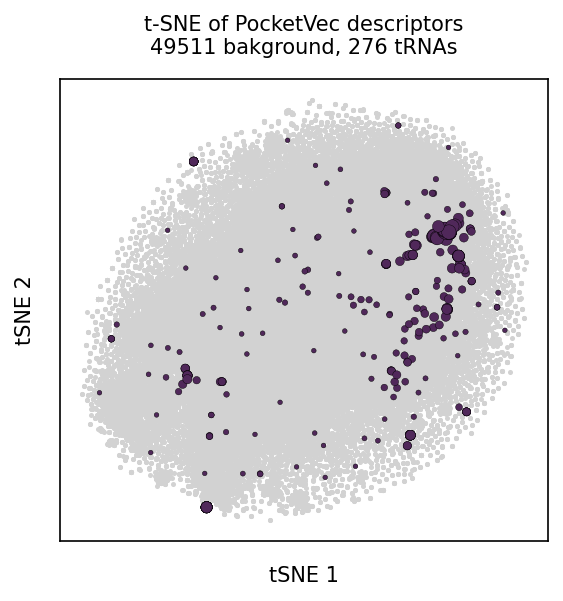

In [ ]:
plt.figure(figsize=(4.2, 4))
plt.scatter(X_embedded[ind_background][:, 0], X_embedded[ind_background][:, 1], s=2, c='#D2D2D2', alpha=1)
plt.scatter(X_embedded[ind_tRNA][:, 0], X_embedded[ind_tRNA][:, 1], s=sizes, c='#50285A', ec='k', lw=0.2)
plt.title(f"t-SNE of PocketVec descriptors\n{len(ind_background)} bakground, {len(ind_tRNA)} tRNAs", size=10, pad=12)
plt.xlabel("tSNE 1", labelpad=12)
plt.ylabel("tSNE 2", labelpad=12)
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
### tSNE only tRNAs

In [ ]:
# Run tSNE

# Add tRNAs PocketVec descriptors
labels = ["tRNA--" + i for i in sorted(fps_tRNAs)]
X = [fps_tRNAs[i] for i in sorted(fps_tRNAs)]

# Merge everything
X, labels = np.array(X)[:], np.array(labels)[:]

# Run tSNE
tsne = TSNE(n_components=2, perplexity=30, n_jobs=8, random_state=42)
X_embedded_tRNAs = tsne.fit_transform(X)

# Calculate density
density = calculate_density(X_embedded_tRNAs[:, 0], X_embedded_tRNAs[:, 1], bandwidth=0.1)

# Calculate sizes
min_size, max_size = 5, 50
sizes = min_size + (density - min(density)) / (max(density) - min(density)) * (max_size - min_size)

# Get the protein for each PocketVec descriptor
proteins = [i.split("_")[1] for i in labels]
protein_to_index = {i:c for c,i in enumerate(set(proteins))}

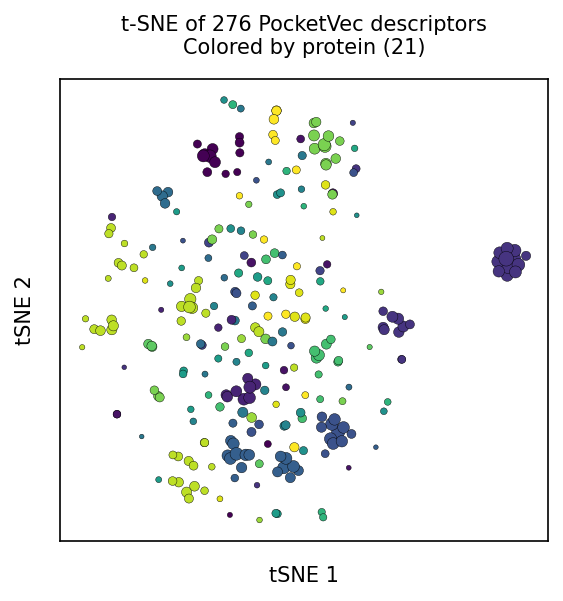

In [ ]:
plt.figure(figsize=(4.2, 4))
plt.scatter(X_embedded_tRNAs[:, 0], X_embedded_tRNAs[:, 1], s=sizes, c=[protein_to_index[i] for i in proteins], ec='k', lw=0.2)
plt.title(f"t-SNE of {len(X_embedded_tRNAs)} PocketVec descriptors\nColored by protein ({len(protein_to_index)})", size=10, pad=12)
plt.xlabel("tSNE 1", labelpad=12)
plt.ylabel("tSNE 2", labelpad=12)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
# For each protein, get list of pockets
protein_to_pockets = {}
for p in sorted(set(proteins)):
    protein_to_pockets[p] = [i for i in fps_tRNAs if i.split("_")[1] == p]

In [ ]:
[len(protein_to_pockets[i]) for i in sorted(protein_to_pockets)], len(protein_to_pockets), len(fps_tRNAs)  

([40, 12, 9, 22, 12, 12, 13, 9, 5, 7, 19, 20, 6, 8, 14, 9, 14, 5, 10, 5, 25],
 21,
 276)

In [ ]:
def get_min_pocketvec_distance(fps1, fps2):
    """
    Get the minimum distance between two PocketVec descriptors
    """
    return np.min(pairwise_distances(fps1, fps2, metric='cosine').flatten())   


def get_min_pocketvec_distance_same_protein(fps1, fps2):
    """
    Get the minimum distance between two PocketVec descriptors,
    using only the upper triangle of the distance matrix.
    """
    dists = pairwise_distances(fps1, fps2, metric='cosine')
    triu_indices = np.triu_indices_from(dists, k=1)
    return np.min(dists[triu_indices])  

def binarize_distance(value, threshold=0.15):
    """
    Binaruze distance values
    """
    if value <= threshold:
        return 1
    else:
        return 0

In [ ]:
X = np.zeros((len(set(proteins)), len(set(proteins))))    

for c1, p1 in enumerate(sorted(set(proteins))):
    for c2, p2 in enumerate(sorted(set(proteins))):
            
            # Get the PocketVec descriptors
            fps1 = np.array([fps_tRNAs[i] for i in protein_to_pockets[p1]])
            fps2 = np.array([fps_tRNAs[i] for i in protein_to_pockets[p2]])
            
            if p1 != p2:

                # Get the minimum distance
                min_distance = get_min_pocketvec_distance(fps1, fps2)
                X[c1, c2] = min_distance
                X[c2, c1] = binarize_distance(min_distance)

            else:

                # Get the minimum distance
                min_distance = get_min_pocketvec_distance_same_protein(fps1, fps2)
                X[c1, c2] = min_distance

            print(f"Distance between {p1} and {p2}: {min_distance}")

Distance between P9WFS9 and P9WFS9: 0.05995279013073773
Distance between P9WFS9 and P9WFT1: 0.12956406660030817
Distance between P9WFS9 and P9WFT3: 0.1395829562935479
Distance between P9WFS9 and P9WFT5: 0.1350471676771331
Distance between P9WFS9 and P9WFT7: 0.15143991493982445
Distance between P9WFS9 and P9WFT9: 0.15296268437245508
Distance between P9WFS9 and P9WFU1: 0.1265354323776121
Distance between P9WFS9 and P9WFU3: 0.15259224278345862
Distance between P9WFS9 and P9WFU5: 0.1296686951407119
Distance between P9WFS9 and P9WFU9: 0.14771146276355074
Distance between P9WFS9 and P9WFV1: 0.12590206768618217
Distance between P9WFS9 and P9WFV3: 0.1179404013211478
Distance between P9WFS9 and P9WFV5: 0.15707006153289305
Distance between P9WFS9 and P9WFV7: 0.14557647497964
Distance between P9WFS9 and P9WFV9: 0.15755785675504497
Distance between P9WFS9 and P9WFW1: 0.15769649764950677
Distance between P9WFS9 and P9WFW3: 0.1661218441769975
Distance between P9WFS9 and P9WFW5: 0.16206112568998277
D

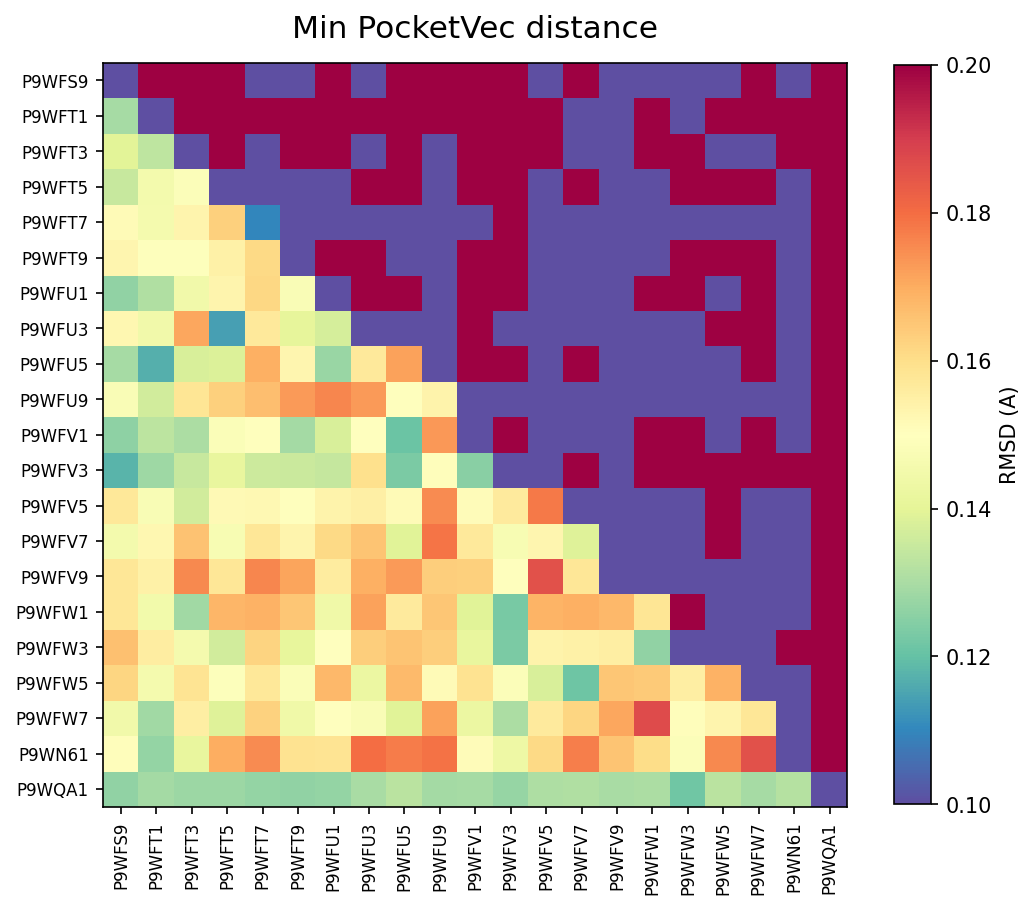

In [ ]:
size = 8
plt.figure(figsize=(8, 8))
plt.imshow(X, vmin=0.10, vmax=0.20, cmap='Spectral_r')
plt.xticks(range(len(set(proteins))), sorted(set(proteins)), rotation=90, size=size)
plt.yticks(range(len(set(proteins))), sorted(set(proteins)), size=size)
plt.title("Min PocketVec distance", pad=12, size=15)
plt.colorbar(shrink=0.8, label="RMSD (A)")
plt.show()